# 📊 Business Performance Analysis & Reporting

# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load Dataset

In [ ]:
df = pd.read_csv('Sales Dataset.csv')

# Showing few rows of dataset
df.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12


In [ ]:
# Checking how many rows and column
df.info()

# Checking the data type of each columns
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1194 non-null   object
 1   Amount        1194 non-null   int64 
 2   Profit        1194 non-null   int64 
 3   Quantity      1194 non-null   int64 
 4   Category      1194 non-null   object
 5   Sub-Category  1194 non-null   object
 6   PaymentMode   1194 non-null   object
 7   Order Date    1194 non-null   object
 8   CustomerName  1194 non-null   object
 9   State         1194 non-null   object
 10  City          1194 non-null   object
 11  Year-Month    1194 non-null   object
dtypes: int64(3), object(9)
memory usage: 112.1+ KB


,0
Order ID,object
Amount,int64
Profit,int64
Quantity,int64
Category,object
Sub-Category,object
PaymentMode,object
Order Date,object
CustomerName,object
State,object


In [ ]:
# Checking the missing values in dataset
df.isnull().sum()

,0
Order ID,0
Amount,0
Profit,0
Quantity,0
Category,0
Sub-Category,0
PaymentMode,0
Order Date,0
CustomerName,0
State,0


In [ ]:
# Converting the Date column to string to datetime formate
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year-Month'] = pd.to_datetime(df['Year-Month'])

df.dtypes

,0
Order ID,object
Amount,int64
Profit,int64
Quantity,int64
Category,object
Sub-Category,object
PaymentMode,object
Order Date,datetime64[ns]
CustomerName,object
State,object


# Operational Insights
- Working with SQLite
- Find the Insights

In [ ]:
# Import SQLite in Notebook
import sqlite3 as sp

# Connect the SQL
connt = sp.connect('Sales.db')
cursor = connt.cursor()

# Insert the data to SQL
df.to_sql(
    name='Sales',
    con=connt,
    if_exists='replace',
    index=False
    )

1194

In [ ]:
# Identifing the Most used payment methord

payment_insights = pd.read_sql_query("""
SELECT
PaymentMode,
COUNT(*) AS Total_order
FROM Sales
GROUP BY PaymentMode
ORDER by Total_order DESC
""",connt)

payment_insights


,PaymentMode,Total_order
0,Debit Card,260
1,Credit Card,258
2,UPI,252
3,EMI,218
4,COD,206


- As we see most order are placed using Debit card
- Credit Card is on the second method which used the most
- COD is the less using payment method is all
- Customer mostly use the digital method not the cash

In [ ]:
# Identifing the Top 10 city by Number of Orders

city_insights = pd.read_sql_query("""
SELECT
City,
COUNT(*) AS Total_orders
FROM Sales
GROUP BY City
ORDER BY Total_orders DESC;
""",connt)


# Showing Top 10 city
city_insights.head(10)


,City,Total_orders
0,Buffalo,90
1,San Francisco,84
2,Orlando,77
3,Rochester,74
4,San Diego,73
5,Dallas,72
6,Cleveland,70
7,Springfield,68
8,Miami,66
9,Austin,65


# Product Analysis

In [ ]:
# Product Insights find premium-priced products with low sales

product_insights = pd.read_sql_query("""
SELECT
"Sub-Category",
AVG(Amount) AS Avg_price,
SUM(Quantity) AS Total_unit_sold
FROM Sales
GROUP BY "Sub-Category"
ORDER BY Avg_price DESC,Total_unit_sold ASC;
""",connt)

product_insights

,Sub-Category,Avg_price,Total_unit_sold
0,Printers,5961.673684,1124
1,Markers,5707.954545,1173
2,Electronic Games,5433.576923,1220
3,Binders,5417.056338,688
4,Chairs,5204.385542,875
5,Tables,5124.401639,1303
6,Paper,5045.721154,981
7,Sofas,4985.675439,1233
8,Phones,4980.742574,980
9,Pens,4844.464912,1204


In [ ]:
# Identify most popular product categories

category_insights = pd.read_sql_query("""
SELECT
"Category",
SUM("Quantity") AS Total_Unit_sold
FROM Sales
GROUP BY "Category"
ORDER BY Total_Unit_sold DESC;""",connt)

category_insights

,Category,Total_Unit_sold
0,Furniture,4441
1,Electronics,4258
2,Office Supplies,4046


- Furniture is the most selling item
- Office Supplies least popular product


# Data Visualization

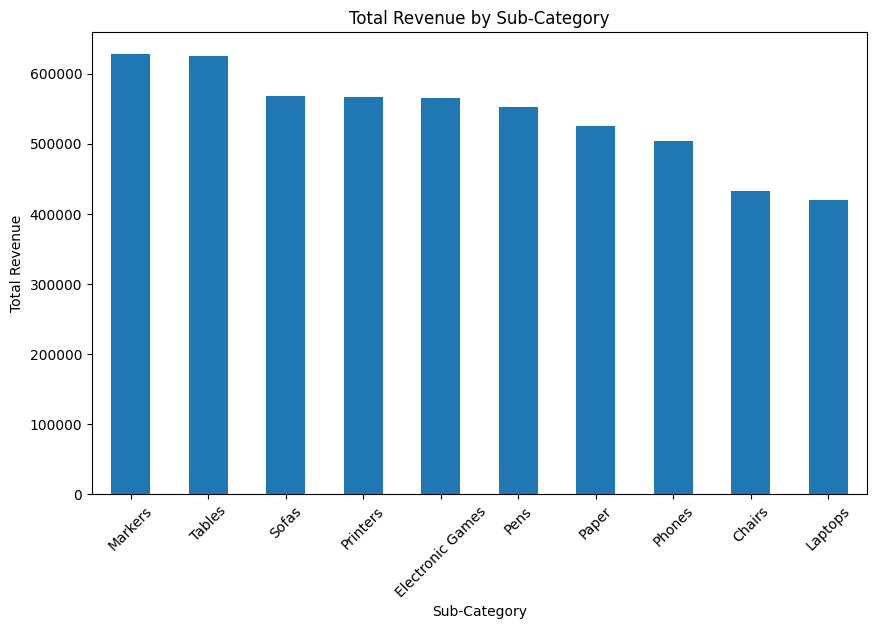

In [ ]:
# Group By Sub-Category And Calculate Total Revenue
#  Top 10 Products by Revenue

Top_products = (
    df.groupby('Sub-Category')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot the bar chart
plt.figure(figsize=(10,6))
Top_products.plot(kind='bar')
plt.title('Total Revenue by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

- These are the top 10 products.
- Markers are the top revenue product.
- Tables are the second top products.
- Laptops are the lowest revenue products from all of these.

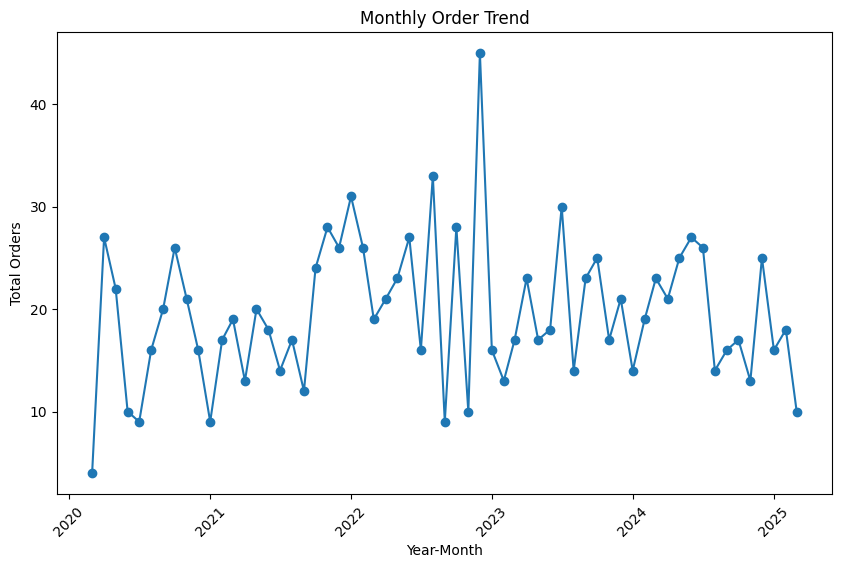

In [ ]:
# Monthly Order Trend

monthly_order_trend = (
    df.groupby('Year-Month')
    .size() # This counts the number of rows (orders) for each Year-Month
)

# Plot Line Chart
plt.figure(figsize=(10,6))
plt.plot(monthly_order_trend.index,monthly_order_trend.values,marker='o')
plt.title('Monthly Order Trend')
plt.xlabel('Year-Month')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.show()

- This plot tells us the highest monthly orders volume.
- In 2020 its start with hike and mid of that year it's fall again then End of the year its again jump in orders volume.
- End of 2022 is the biggest jump in orders volume out of Five years.
- Lastly the 2025 is order volume started to fall again.

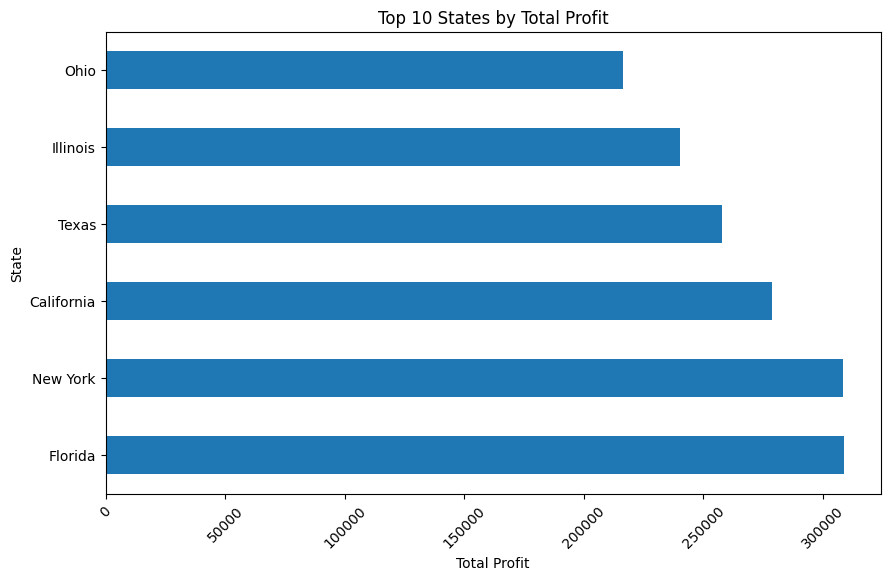

In [ ]:
# Top 10 States by Total Profit

top_states = (
    df.groupby('State')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_states.plot(kind='barh')
plt.title('Top 10 States by Total Profit')
plt.xlabel('Total Profit')
plt.ylabel('State')
plt.xticks(rotation=45)
plt.show()

- Top 10 States of the Total profit.
- Florida and New York are highest Profit in out of Total Profit States.
- Ohio is lowest profit in all of these State's.

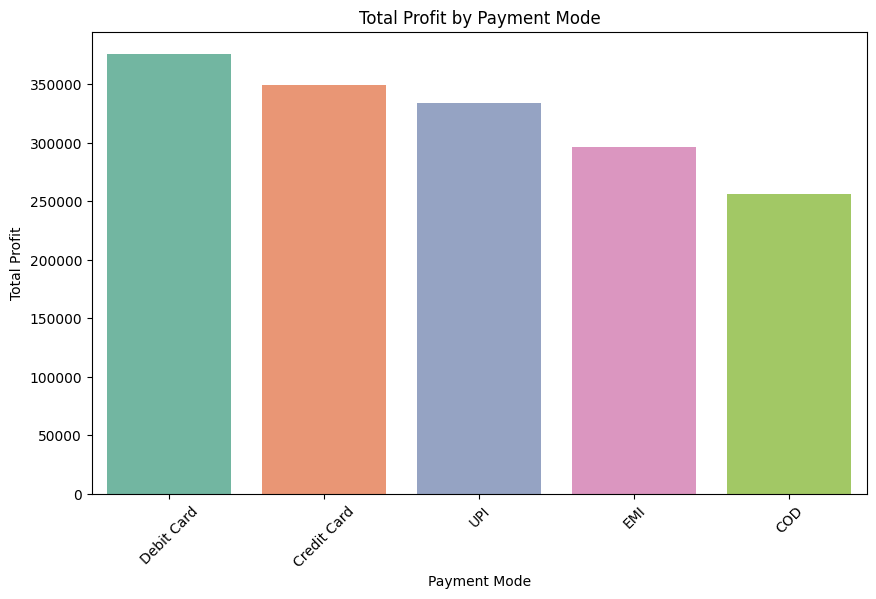

In [ ]:
# Total Profit by Payment Mode

profitable_method = (
    df.groupby('PaymentMode')['Profit']
    .sum()
    .sort_values(ascending=False)
)

# Plot bar chart using seaborn
plt.figure(figsize=(10,6))
sns.barplot(x=profitable_method.index,
            y=profitable_method.values,
            palette='Set2',
            hue=profitable_method.index)
plt.title('Total Profit by Payment Mode')
plt.xlabel('Payment Mode')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.show()

- As we discuss thats Debit Card is the highest using payment method.
- Credit Card are the Second most used method.
- COD the lowest method customer used for payment.
- Conclusion is Digital payment is used more than cash payment.

# Export Business Reports

In [ ]:
# Top 10 Products by Revenue

Top10_products = (
    df.groupby(['Category','Sub-Category'])['Amount']
    .sum()
    .reset_index()
    .sort_values(by='Amount',ascending=False)
    .head(10)
    .rename(columns={
        'Category':'Top Category',
        'Sub-Category': 'Top Sub-Category',
        'Amount': 'Total Revenue'
    })
    )
Top10_products

,Top Category,Top Sub-Category,Total Revenue
9,Office Supplies,Markers,627875
7,Furniture,Tables,625177
6,Furniture,Sofas,568367
3,Electronics,Printers,566359
0,Electronics,Electronic Games,565092
11,Office Supplies,Pens,552269
10,Office Supplies,Paper,524755
2,Electronics,Phones,503055
5,Furniture,Chairs,431964
1,Electronics,Laptops,419950


- Top 10 products by revenue.
- Group by the Categories and Sub-Categories to find out Highest and lowest by revenue.
- Office Supplies is the highest revenue Category and Markers are highest revenue Sub-Category.
- Furniture is the second highest Category and in Furniture Tables is the highest revenue product.

In [ ]:
# Monthly Order Volume

monthly_order_volume = (
    df['Year-Month']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={
        'index': 'Month',
        'Year-Month': 'Number of Orders'
    })
    .head(10)
)

monthly_order_volume


,Number of Orders,count
0,2020-03-01,4
1,2020-04-01,27
2,2020-05-01,22
3,2020-06-01,10
4,2020-07-01,9
5,2020-08-01,16
6,2020-09-01,20
7,2020-10-01,26
8,2020-11-01,21
9,2020-12-01,16


- Use the Year-Month column to count the number of orders per month.
- Sort the months in chronological order.
- We take only the first 10 months to match the number of rows from the Top Products table.

In [ ]:
# Combine Both Dataset

Business_report = (
    pd.concat([Top10_products,monthly_order_volume],axis=1)
)


# Export the Report in CSV Format
Business_report.to_csv( "top_products_and_monthly_orders.csv",index=False)

- Combine both Tables to make a report.
- Export the Report in CSV file.